In [28]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [29]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3    # RGB
EPOCHS = 5

In [30]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "PlantVillage",
    shuffle = True,
    image_size = (IMAGE_SIZE,IMAGE_SIZE),
    batch_size = BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [31]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [32]:
len(dataset)

68

(32, 256, 256, 3)
[1 0 1 1 1 1 1 0 0 1 2 0 1 0 1 1 1 2 1 0 1 0 0 1 0 2 0 1 0 0 0 1]
tf.Tensor(
[[[115. 102. 109.]
  [115. 102. 109.]
  [115. 102. 109.]
  ...
  [118. 105. 112.]
  [126. 113. 120.]
  [138. 125. 132.]]

 [[126. 113. 120.]
  [127. 114. 121.]
  [128. 115. 122.]
  ...
  [128. 115. 122.]
  [125. 112. 119.]
  [124. 111. 118.]]

 [[118. 105. 112.]
  [123. 110. 117.]
  [126. 113. 120.]
  ...
  [129. 116. 123.]
  [124. 111. 118.]
  [120. 107. 114.]]

 ...

 [[141. 135. 139.]
  [149. 143. 147.]
  [156. 150. 154.]
  ...
  [155. 146. 151.]
  [158. 149. 154.]
  [154. 145. 150.]]

 [[153. 147. 151.]
  [159. 153. 157.]
  [161. 155. 159.]
  ...
  [159. 150. 155.]
  [145. 136. 141.]
  [147. 138. 143.]]

 [[144. 138. 142.]
  [151. 145. 149.]
  [155. 149. 153.]
  ...
  [162. 153. 158.]
  [151. 142. 147.]
  [171. 162. 167.]]], shape=(256, 256, 3), dtype=float32)
(32, 256, 256, 3)
[1 0 1 1 1 1 1 0 0 1 2 0 1 0 1 1 1 2 1 0 1 0 0 1 0 2 0 1 0 0 0 1]
tf.Tensor(
[[[207. 206. 212.]
  [208. 207. 213

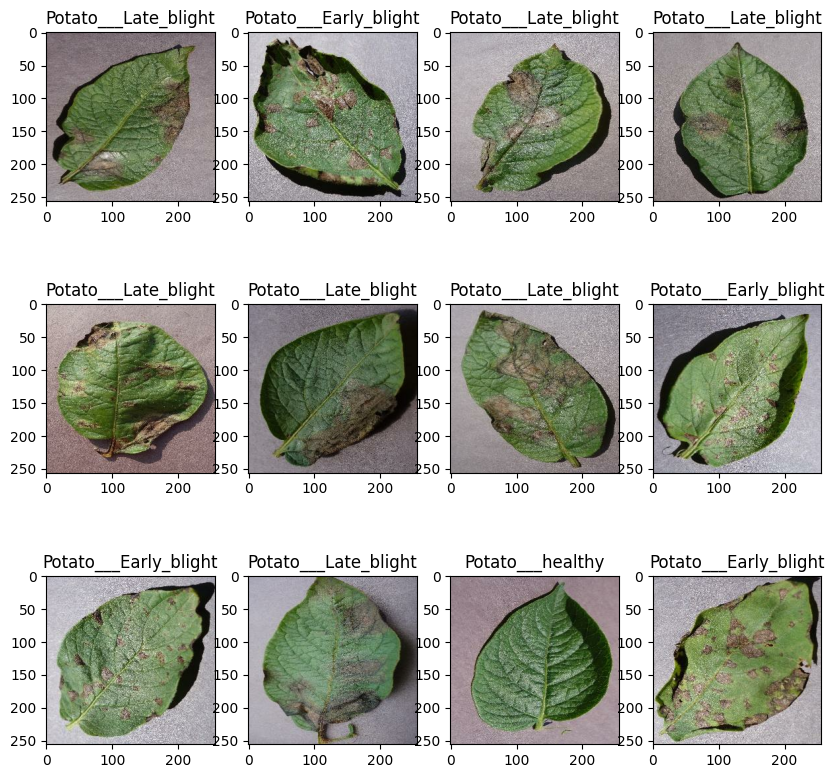

In [33]:
plt.figure(figsize=(10,10))
for image_batch,label_batch in dataset.take(1):
    for i in range(12):
        print(image_batch.shape)
        print(label_batch.numpy())
        print(image_batch[i])
        ax = plt.subplot(3,4,i+1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]])


### Spliting the dataset into train-test-split (80-10-10)

In [34]:
train_size = 0.8   # Training percentage = 80%
len(dataset)*train_size  # 68 * 0.8 = 54.40 = take first 54 batches(each batch has 32 samples) to train the model

54.400000000000006

In [35]:
train_Ds = dataset.take(54)
len(train_Ds)

54

In [36]:
rest_Ds = dataset.skip(54)   # skip the first 54 batches and rest one will be for test and validation set
len(rest_Ds)

14

In [37]:
validation_size = 0.1    # 10% validation set
len(dataset)*validation_size

6.800000000000001

In [38]:
val_Ds = rest_Ds.take(6)
len(val_Ds)

6

In [39]:
test_ds = rest_Ds.skip(6)
len(test_ds)

8

In [40]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(ds_size*train_split)
    val_size = int(ds_size*val_split)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds,val_ds,test_ds

In [41]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [42]:
print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

54
6
8


### Image caching , prefetching -- dataset is optimized for training performance

In [43]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

### Image Preprocessing

In [44]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0 / 255)
])

In [45]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

### Model Building : CNN

In [46]:
input_shape = (BATCH_SIZE,IMAGE_SIZE,IMAGE_SIZE,CHANNELS)
n_classes = 3
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3),activation='relu',input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size = (3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes,activation='softmax'),
])
model.build(input_shape = input_shape)

f:\My Projects\potato-disease\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [47]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (32, 256, 256, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (32, 254, 254, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (32, 127, 127, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (32, 125, 125, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (32, 62, 62, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (32, 60, 60, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (32, 30, 30, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (32, 28, 28, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (32, 14, 14, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (32, 12, 12, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (32, 6, 6, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (32, 4, 4, 64)         │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (32, 2, 2, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (32, 256)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 64)               │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 3)                │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [49]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.4745 - loss: 0.9144 - val_accuracy: 0.5365 - val_loss: 0.7792
Epoch 2/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.6690 - loss: 0.6675 - val_accuracy: 0.7760 - val_loss: 0.4610
Epoch 3/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.7963 - loss: 0.4414 - val_accuracy: 0.8333 - val_loss: 0.4342
Epoch 4/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 136s 3s/step - accuracy: 0.8374 - loss: 0.3834 - val_accuracy: 0.8385 - val_loss: 0.5487
Epoch 5/5
54/54 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - accuracy: 0.8571 - loss: 0.3377 - val_accuracy: 0.8438 - val_loss: 0.3641


### Testing the Model

In [50]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8516 - loss: 0.3518


In [ ]:
scores # scores = [loss,accuracy]

[0.3517960011959076, 0.8515625]

### Plotting & visualization

In [52]:
history

In [53]:
history.params

{'verbose': 1, 'epochs': 5, 'steps': 54}

In [54]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [55]:
history.history['accuracy']

[0.47453704476356506,
 0.6689814925193787,
 0.7962962985038757,
 0.8373842835426331,
 0.8570601940155029]

In [57]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

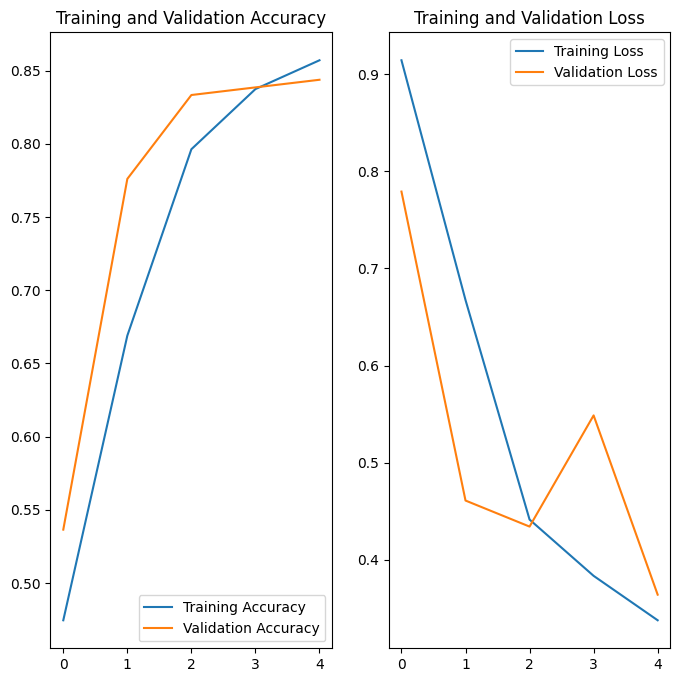

In [59]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS),acc,label='Training Accuracy')
plt.plot(range(EPOCHS),val_acc,label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(range(EPOCHS),loss,label='Training Loss')
plt.plot(range(EPOCHS),val_loss,label='Validation Loss')
plt.legend(loc='upper right')
plt.title("Training and Validation Loss")
plt.show()


### Prediction 